Name:    Sentinel-2 Water Quality (Se2WaQ)    
Version: 1.0           
Date:    2020-01-31         

Author:      Nuno Sidónio Andrade Pereira            
Affiliation: Polytechnic Institute of Beja, Portugal              
License:     Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)            

Refs.:             
       [1]M. Potes et al., “Use of Sentinel 2 – MSI for water quality 
          monitoring at Alqueva reservoir, Portugal,” Proc. Int. Assoc. 
          Hydrol. Sci., vol. 380, pp. 73–79, Dec. 2018.

       [2]K. Toming, T. Kutser, A. Laas, M. Sepp, B. Paavel, and T. Nõges,
          “First Experiences in Mapping Lake Water Quality Parameters with
          Sentinel-2 MSI Imagery,” Remote Sens., vol. 8, no. 8, p. 640, 
          Aug. 2016.

In [4]:
import datetime

date = "2019-06-29"
date_1 = datetime.datetime.strptime(date, "%Y-%m-%d")

start_date = date_1 - datetime.timedelta(days=4)
end_date = date_1 + datetime.timedelta(days=4)

start_date = start_date.strftime("%Y-%m-%d")
end_date = end_date.strftime("%Y-%m-%d")


print(start_date)
print(end_date)

#area of interest
#aoi = 'POLYGON((-53.6565 82.4951, -59.9608 82.1309, -67.7892 80.5602, -67.9606 80.0218, -67.6072 79.3014, -72.7375 78.5894, -73.5413 78.1636, -72.9428 77.3837, -69.0700 76.0128, -66.6509 75.7624, -60.3956 75.8231, -58.4311 74.8854, -55.1967 69.6980, -53.8565 68.8368, -54.2986 67.0754, -53.5562 65.6109, -52.3863 64.7989, -52.3228 64.0074, -50.2076 62.1010, -48.6300 60.7381, -45.0522 59.7674, -43.2890 59.6436, -42.4957 60.3093, -41.8486 61.5655, -41.6969 62.6486, -40.1106 63.5452, -39.9111 64.7944, -38.0777 65.4068, -36.9899 65.1987, -31.2165 67.7166, -25.8502 68.6303, -21.6517 70.0839, -20.9932 70.7880, -21.2829 72.9254, -16.9050 74.9601, -17.1213 79.6158, -10.2883 81.4244, -14.0398 81.9745, -17.8112 82.0131, -28.5252 83.7013, -40.1075 83.6651, -53.6565 82.4951))'
#aoi = "POLYGON((-14.675905 65.792421,-14.675905 66.238873,-13.423464 66.238873,-13.423464 65.792421,-14.675905 65.792421))')"
#aoi = "POLYGON((12.655118166047592 47.44667197521409,21.39065656328509 48.347694733853245,28.334291357162826 41.877123516783655,17.47086198383573 40.35854475076158,12.655118166047592 47.44667197521409))')"
aoi = "POLYGON ((-7.664532 38.543869, -7.689248 38.141037, -7.159228 38.151837, -7.115289 38.554609, -7.664532 38.543869))')"
date_interval = " and ContentDate/Start gt "+start_date+"T00:00:00.000Z and ContentDate/Start lt "+end_date+"T00:00:00.000Z"

url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=OData.CSC.Intersects(area=geography'SRID=4326;"
collection = " and Collection/Name eq 'SENTINEL-2'"
rq_str = url + aoi + date_interval + collection
print(rq_str)

2019-06-25
2019-07-03
https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=OData.CSC.Intersects(area=geography'SRID=4326;POLYGON ((-7.664532 38.543869, -7.689248 38.141037, -7.159228 38.151837, -7.115289 38.554609, -7.664532 38.543869))') and ContentDate/Start gt 2019-06-25T00:00:00.000Z and ContentDate/Start lt 2019-07-03T00:00:00.000Z and Collection/Name eq 'SENTINEL-2'


In [5]:
import requests
import pandas as pd

#json = requests.get("https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=OData.CSC.Intersects(area=geography'SRID=4326;POLYGON((12.655118166047592 47.44667197521409,21.39065656328509 48.347694733853245,28.334291357162826 41.877123516783655,17.47086198383573 40.35854475076158,12.655118166047592 47.44667197521409))') and ContentDate/Start gt 2022-05-20T00:00:00.000Z and ContentDate/Start lt 2022-05-21T00:00:00.000Z").json()
json = requests.get(rq_str).json()
#print(json)
df = pd.DataFrame.from_dict(json['value'])

# Print only specific columns
columns_to_print = ['Id', 'Name','S3Path','GeoFootprint']  
df[columns_to_print].head(3)

,Id,Name,S3Path,GeoFootprint
0,f5765721-3d1c-505a-8581-a9257786cb7a,S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_2...,/eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL...,"{'type': 'Polygon', 'coordinates': [[[-7.71313..."
1,a8ffd1e8-7834-5fd2-b372-0cd97e791729,S2A_MSIL1C_20190701T110621_N0207_R137_T29SPC_2...,/eodata/Sentinel-2/MSI/L1C/2019/07/01/S2A_MSIL...,"{'type': 'Polygon', 'coordinates': [[[-7.71313..."
2,463b1da5-41b6-5386-ad24-e8eb6cdc1ca5,S2B_MSIL1C_20190629T112119_N0207_R037_T29SPC_2...,/eodata/Sentinel-2/MSI/L1C/2019/06/29/S2B_MSIL...,"{'type': 'Polygon', 'coordinates': [[[-6.59674..."


In [37]:
df['S3Path'].iloc[1]

'/eodata/Sentinel-2/MSI/L1C/2019/07/01/S2A_MSIL1C_20190701T110621_N0207_R137_T29SPC_20190701T113552.SAFE'

In [ ]:
S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE

In [26]:
!s3cmd -c tt.s3cfd get s3:///eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE/GRANULE/L2A_T29SPC_A021012_20190701T111753/IMG_DATA/R10m/T29SPC_20190701T110621_B04_10m.jp2
!s3cmd -c tt.s3cfd get s3:///eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE/GRANULE/L2A_T29SPC_A021012_20190701T111753/IMG_DATA/R10m/T29SPC_20190701T110621_B03_10m.jp2
!s3cmd -c tt.s3cfd get s3:///eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE/GRANULE/L2A_T29SPC_A021012_20190701T111753/IMG_DATA/R10m/T29SPC_20190701T110621_B02_10m.jp2


!s3cmd -c tt.s3cfd get s3:///eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE/GRANULE/L2A_T29SPC_A021012_20190701T111753/IMG_DATA/R10m/T29SPC_20190701T110621_B01_60m.jp2
!s3cmd -c tt.s3cfd get s3:///eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE/GRANULE/L2A_T29SPC_A021012_20190701T111753/IMG_DATA/R10m/T29SPC_20190701T110621_B03_60m.jp2

download: 's3://eodata/Sentinel-2/MSI/L2A/2019/07/01/S2A_MSIL2A_20190701T110621_N0212_R137_T29SPC_20190701T120906.SAFE/GRANULE/L2A_T29SPC_A021012_20190701T111753/IMG_DATA/R10m/T29SPC_20190701T110621_B04_10m.jp2' -> './T29SPC_20190701T110621_B04_10m.jp2'  [1 of 1]
 106750131 of 106750131   100% in    1s    63.26 MB/s  done


In [30]:
# T29SPC_20190701T110621_B02_10m.jp2
# T29SPC_20190701T110621_B03_10m.jp2
#T29SPC_20190701T110621_B04_10m.jp2
 
!gdal_calc.py -A T29SPC_20190701T110621_B02_10m.jp2 -B T29SPC_20190701T110621_B03_10m.jp2 -C T29SPC_20190701T110621_B04_10m.jp2 --calc "115530.31 * power(B * C / A, 2.38)" --outfile T29SPC_20190701T110621_10m_calc_cya.tiff --co=TILED=YES

<string>:1: RuntimeWarning: invalid value encountered in divide
0.. 0.. 1.. 2.. 3.. 4.. 4.. 5.. 6.. 7.. 8.. 9.. 9.. 10.. 11.. 12.. 13.. 14.. 14.. 15.. 16.. 17.. 18.. 19.. 19.. 20.. 21.. 22.. 23.. 23.. 24.. 25.. 26.. 27.. 28.. 28.. 29.. 30.. 31.. 32.. 33.. 33.. 34.. 35.. 36.. 37.. 38.. 38.. 39.. 40.. 41.. 42.. 42.. 43.. 44.. 45.. 46.. 47.. 47.. 48.. 49.. 50.. 51.. 52.. 52.. 53.. 54.. 55.. 56.. 57.. 57.. 58.. 59.. 60.. 61.. 61.. 62.. 63.. 64.. 65.. 66.. 66.. 67.. 68.. 69.. 70.. 71.. 71.. 72.. 73.. 74.. 75.. 76.. 76.. 77.. 78.. 79.. 80.. 80.. 81.. 82.. 83.. 84.. 85.. 85.. 86.. 87.. 88.. 89.. 90.. 90.. 91.. 92.. 93.. 94.. 95.. 95.. 96.. 97.. 98.. 99.. 100 - Done


### Density of cyanobacteria

In [38]:
!gdal_calc.py -A T29SPC_20190701T110621_B02_10m.jp2 -B T29SPC_20190701T110621_B03_10m.jp2 -C T29SPC_20190701T110621_B04_10m.jp2 --calc "115530*(((B.astype(float)*C.astype(float))/A.astype(float))**2.38)" --outfile T29SPC_20190701T110621_10m_calc_cya.tiff --co=TILED=YES --overwrite --type Float32

<string>:1: RuntimeWarning: invalid value encountered in divide
0.. 0.. 1.. 2.. 3.. 4.. 4.. 5.. 6.. 7.. 8.. 9.. 9.. 10.. 11.. 12.. 13.. 14.. 14.. 15.. 16.. 17.. 18.. 19.. 19.. 20.. 21.. 22.. 23.. 23.. 24.. 25.. 26.. 27.. 28.. 28.. 29.. 30.. 31.. 32.. 33.. 33.. 34.. 35.. 36.. 37.. 38.. 38.. 39.. 40.. 41.. 42.. 42.. 43.. 44.. 45.. 46.. 47.. 47.. 48.. 49.. 50.. 51.. 52.. 52.. 53.. 54.. 55.. 56.. 57.. 57.. 58.. 59.. 60.. 61.. 61.. 62.. 63.. 64.. 65.. 66.. 66.. 67.. 68.. 69.. 70.. 71.. 71.. 72.. 73.. 74.. 75.. 76.. 76.. 77.. 78.. 79.. 80.. 80.. 81.. 82.. 83.. 84.. 85.. 85.. 86.. 87.. 88.. 89.. 90.. 90.. 91.. 92.. 93.. 94.. 95.. 95.. 96.. 97.. 98.. 99.. 100 - Done


### Concentration of Chlorophyll a

In [39]:
!gdal_calc.py -A T29SPC_20190701T110621_B01_60m.jp2 -C T29SPC_20190701T110621_B03_60m.jp2 --calc "4.26*((C/A)**3.94)" --outfile T29SPC_20190701T110621_10m_calc_chla.tiff --co=TILED=YES --overwrite --type Float32

<string>:1: RuntimeWarning: invalid value encountered in divide
0.. 1.. 2.. 3.. 4.. 5.. 6.. 7.. 8.. 9.. 10.. 11.. 12.. 13.. 14.. 15.. 16.. 17.. 18.. 19.. 20.. 21.. 22.. 23.. 24.. 25.. 26.. 27.. 28.. 29.. 30.. 31.. 32.. 33.. 34.. 35.. 36.. 37.. 38.. 39.. 40.. 41.. 42.. 43.. 44.. 45.. 46.. 47.. 48.. 49.. 50.. 51.. 52.. 53.. 54.. 55.. 56.. 57.. 58.. 59.. 60.. 61.. 62.. 63.. 64.. 65.. 66.. 67.. 68.. 69.. 70.. 71.. 72.. 73.. 74.. 75.. 76.. 77.. 78.. 79.. 80.. 81.. 82.. 83.. 84.. 85.. 86.. 87.. 88.. 89.. 90.. 91.. 92.. 93.. 94.. 95.. 96.. 97.. 98.. 99.. 100 - Done


### Turbidity

In [62]:
!gdal_calc.py -A T29SPC_20190701T110621_B01_60m.jp2 -C T29SPC_20190701T110621_B03_60m.jp2 --calc "(8.93*(C/A))-6.39" --outfile T29SPC_20190701T110621_10m_calc_turb.tiff --co=TILED=YES --overwrite --type Float32

<string>:1: RuntimeWarning: invalid value encountered in divide
0.. 1.. 2.. 3.. 4.. 5.. 6.. 7.. 8.. 9.. 10.. 11.. 12.. 13.. 14.. 15.. 16.. 17.. 18.. 19.. 20.. 21.. 22.. 23.. 24.. 25.. 26.. 27.. 28.. 29.. 30.. 31.. 32.. 33.. 34.. 35.. 36.. 37.. 38.. 39.. 40.. 41.. 42.. 43.. 44.. 45.. 46.. 47.. 48.. 49.. 50.. 51.. 52.. 53.. 54.. 55.. 56.. 57.. 58.. 59.. 60.. 61.. 62.. 63.. 64.. 65.. 66.. 67.. 68.. 69.. 70.. 71.. 72.. 73.. 74.. 75.. 76.. 77.. 78.. 79.. 80.. 81.. 82.. 83.. 84.. 85.. 86.. 87.. 88.. 89.. 90.. 91.. 92.. 93.. 94.. 95.. 96.. 97.. 98.. 99.. 100 - Done


Data range: 0.03776268661022186 to 121385.5078125


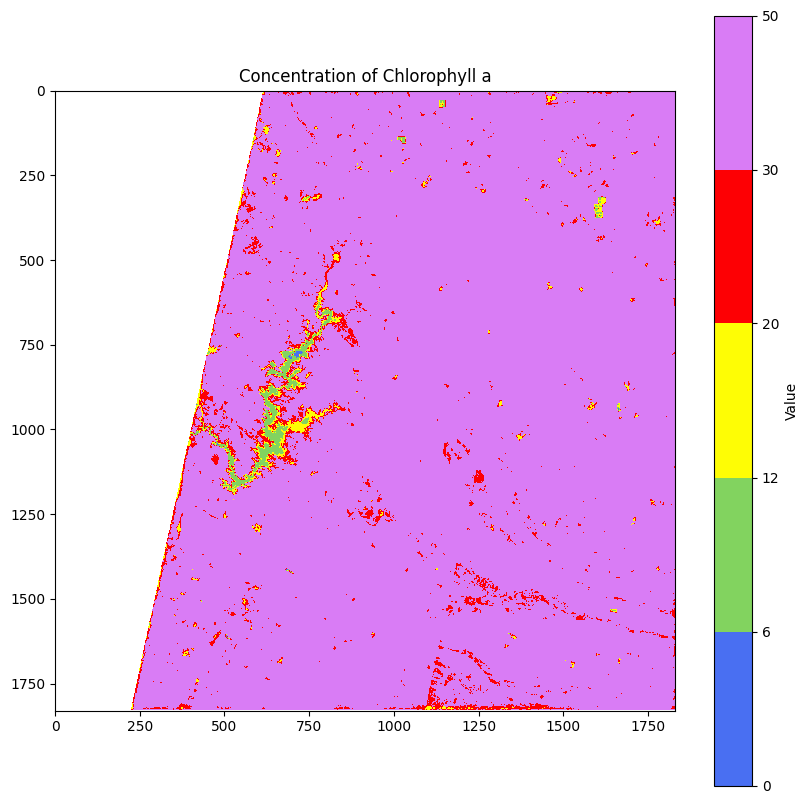

In [59]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def load_and_plot_geotiff_gdal(filename):
    # Open the dataset
    dataset = gdal.Open(filename)
    if not dataset:
        print("Unable to open file.")
        return

    # Read the first band
    band = dataset.GetRasterBand(1)
    if not band:
        print("Unable to get the band from file.")
        return

    # Read data into numpy array
    data = band.ReadAsArray().astype(float)

    # Handle NoData values
    nodata = band.GetNoDataValue()
    if nodata is not None:
        data[data == nodata] = np.nan

    # Check if the data is valid
    if np.isnan(data).all():
        print("The band contains only NaN values.")
        return

    # Custom color scale from your data
    scaleChl_a = [0, 6, 12, 20, 30, 50]
    colorScale = [
        [73/255, 111/255, 242/255],
        [130/255, 211/255, 95/255],
        [254/255, 253/255, 5/255],
        [253/255, 0/255, 4/255],
        [142/255, 32/255, 38/255],
        [217/255, 124/255, 245/255]
    ]

    # Create a colormap object
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colorScale, N=len(scaleChl_a))

    # Normalize the data to fit the scale
    data_min, data_max = np.nanmin(data), np.nanmax(data)
    print(f"Data range: {data_min} to {data_max}")
    norm = mcolors.BoundaryNorm(scaleChl_a, cmap.N)

    # Plotting
    plt.figure(figsize=(10, 10))
    img = plt.imshow(data, cmap=cmap, norm=norm)
    plt.colorbar(img, label='Value', boundaries=scaleChl_a, ticks=scaleChl_a)
    plt.title('Concentration of Chlorophyll a')
    plt.show()

    
load_and_plot_geotiff_gdal('T29SPC_20190701T110621_10m_calc_chla.tiff')


Data range: -3.6987671852111816 to 114.25254821777344


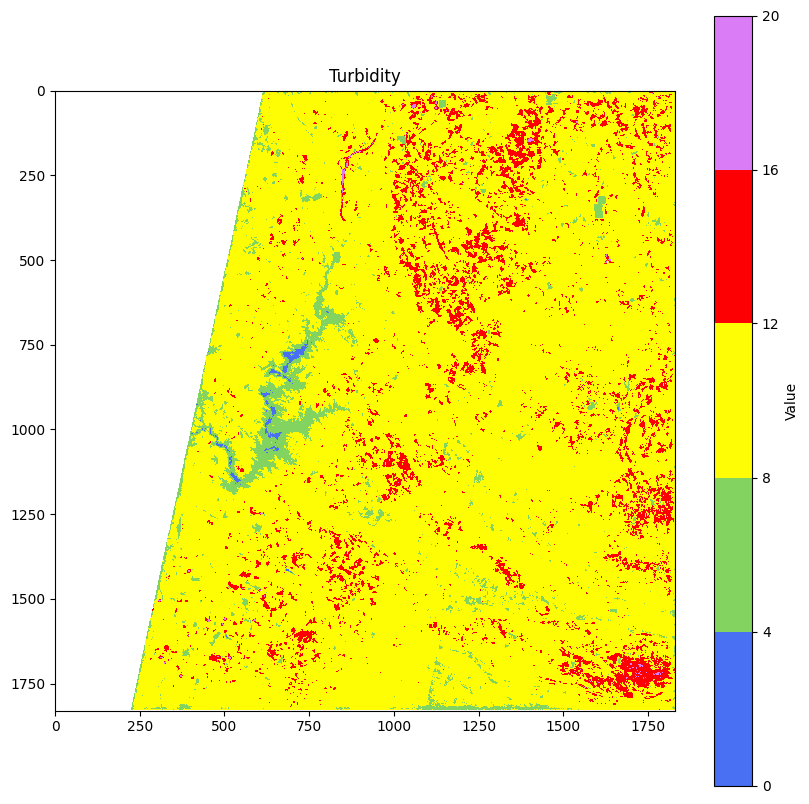

In [65]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def load_and_plot_geotiff_gdal(filename):
    # Open the dataset
    dataset = gdal.Open(filename)
    if not dataset:
        print("Unable to open file.")
        return

    # Read the first band
    band = dataset.GetRasterBand(1)
    if not band:
        print("Unable to get the band from file.")
        return

    # Read data into numpy array
    data = band.ReadAsArray().astype(float)

    # Handle NoData values
    nodata = band.GetNoDataValue()
    if nodata is not None:
        data[data == nodata] = np.nan

    # Check if the data is valid
    if np.isnan(data).all():
        print("The band contains only NaN values.")
        return

    # Custom color scale from your data
    scaleChl_a = [0, 4, 8, 12, 16, 20]
    colorScale = [
        [73/255, 111/255, 242/255],
        [130/255, 211/255, 95/255],
        [254/255, 253/255, 5/255],
        [253/255, 0/255, 4/255],
        [142/255, 32/255, 38/255],
        [217/255, 124/255, 245/255]
    ]

    # Create a colormap object
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colorScale, N=len(scaleChl_a))

    # Normalize the data to fit the scale
    data_min, data_max = np.nanmin(data), np.nanmax(data)
    print(f"Data range: {data_min} to {data_max}")
    norm = mcolors.BoundaryNorm(scaleChl_a, cmap.N)

    # Plotting
    plt.figure(figsize=(10, 10))
    img = plt.imshow(data, cmap=cmap, norm=norm)
    plt.colorbar(img, label='Value', boundaries=scaleChl_a, ticks=scaleChl_a)
    plt.title('Turbidity')
    plt.show()

    
load_and_plot_geotiff_gdal('T29SPC_20190701T110621_10m_calc_turb.tiff')